# ICS1512 – Machine Learning Laboratory
## Experiment 6: Bagging, Boosting, and Stacked Ensemble Models

**Institution:** Sri Sivasubramaniya Nadar College of Engineering, Chennai  
**Degree & Branch:** B.E. Computer Science & Engineering  
**Semester:** VI  
**Academic Year:** 2026–2027 (Even)  
**Batch:** 2024–2029  
**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC)

### Objectives
- Understand Bagging, Boosting, and Stacking.
- Implement Bagging, AdaBoost, and Gradient Boosting.
- Construct a heterogeneous Stacked Ensemble.
- Select hyperparameters using 5-fold cross-validation.
- Compare accuracy, precision, recall, F1-score, ROC-AUC, stability, and generalization.
- Analyze the effect of ensemble methods on bias and variance.

> **Reproducibility:** A fixed random seed is used throughout. All final test metrics are computed only on the held-out 20% test set.


## 1. Import Libraries

In [1]:
import sys
import platform
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score, precision_recall_curve, average_precision_score
)

RANDOM_STATE = 42
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

print("Python:", sys.version.split()[0])
print("Scikit-learn:", sklearn.__version__)
print("Platform:", platform.platform())


Python: 3.13.15
Scikit-learn: 1.6.1
Platform: Linux-6.6.122+-x86_64-with-glibc2.39


## 2. Load the Wisconsin Diagnostic Breast Cancer Dataset

In [2]:
# The scikit-learn copy is derived from the Wisconsin Diagnostic Breast Cancer dataset.
# It contains 569 samples, 30 numerical features, and two classes.

data = load_breast_cancer(as_frame=True)
X = data.data.copy()

# sklearn encodes malignant=0 and benign=1 in target.
# For readable reporting, use the original class names.
y = data.target.copy()

print("Dataset shape:", X.shape)
print("Number of features:", X.shape[1])
print("Target classes:", data.target_names)
display(X.head())


Dataset shape: (569, 30)
Number of features: 30
Target classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Dataset Overview

In [3]:
print("Dataset information:")
display(X.info())

print("\nStatistical summary:")
display(X.describe().T)

print("\nClass distribution:")
class_counts = y.map({0: "Malignant", 1: "Benign"}).value_counts()
display(class_counts.to_frame("Count"))


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoot

None


Statistical summary:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744



Class distribution:


,Count
target,
Benign,357
Malignant,212


## 4. Missing Value Analysis

In [4]:
missing = X.isnull().sum().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": (missing / len(X) * 100).round(2)
})
display(missing_summary[missing_summary["Missing Values"] > 0])

print("Total missing values:", int(X.isnull().sum().sum()))


,Missing Values,Missing Percentage


Total missing values: 0


## 5. Exploratory Data Analysis – Class Distribution

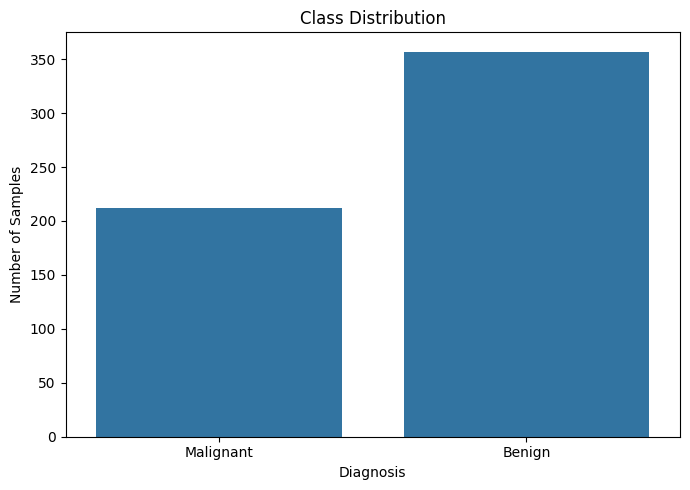

In [5]:
plt.figure(figsize=(7, 5))
sns.countplot(x=y.map({0: "Malignant", 1: "Benign"}))
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


**Inference:** The dataset contains two diagnosis classes, malignant and benign. The class frequencies are not identical, so stratification is used during train-test splitting and cross-validation. This preserves approximately the same class proportions across training, validation, and test subsets. The class distribution is important when interpreting accuracy alongside precision, recall, and F1-score.

## 6. Exploratory Data Analysis – Correlation Matrix

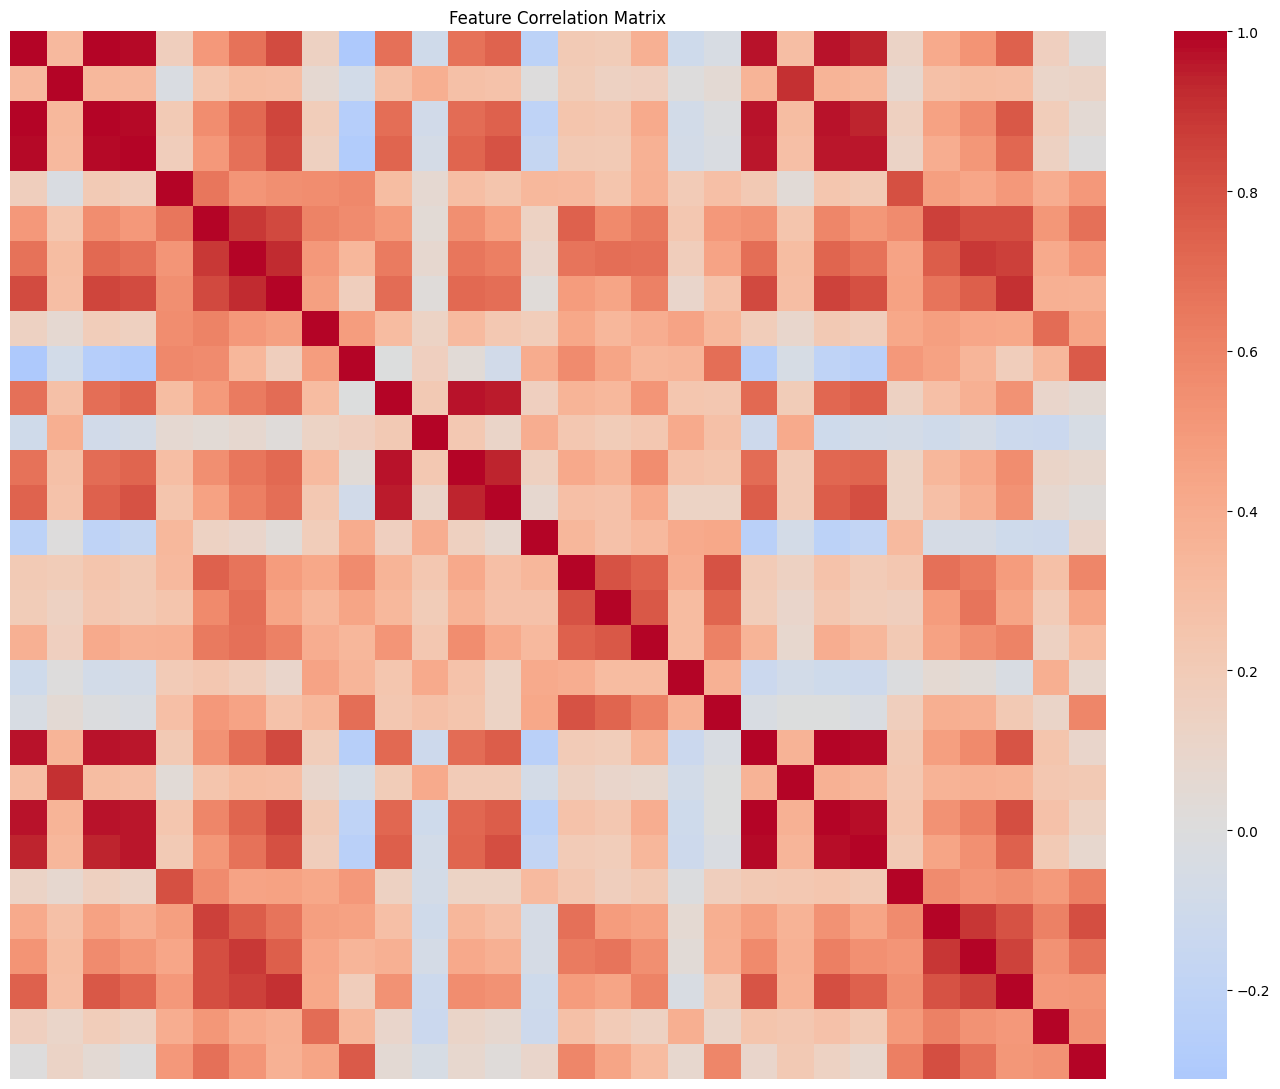

In [6]:
plt.figure(figsize=(14, 11))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


**Inference:** The correlation matrix shows several groups of strongly correlated measurements. Such redundancy is common in the WDBC feature set because multiple variables describe related properties of cell nuclei. Highly correlated predictors can make individual models more sensitive to feature representation, while ensemble methods can combine complementary decision boundaries. Scaling is especially relevant for SVM-based stacking.

## 7. Exploratory Data Analysis – Feature Distributions

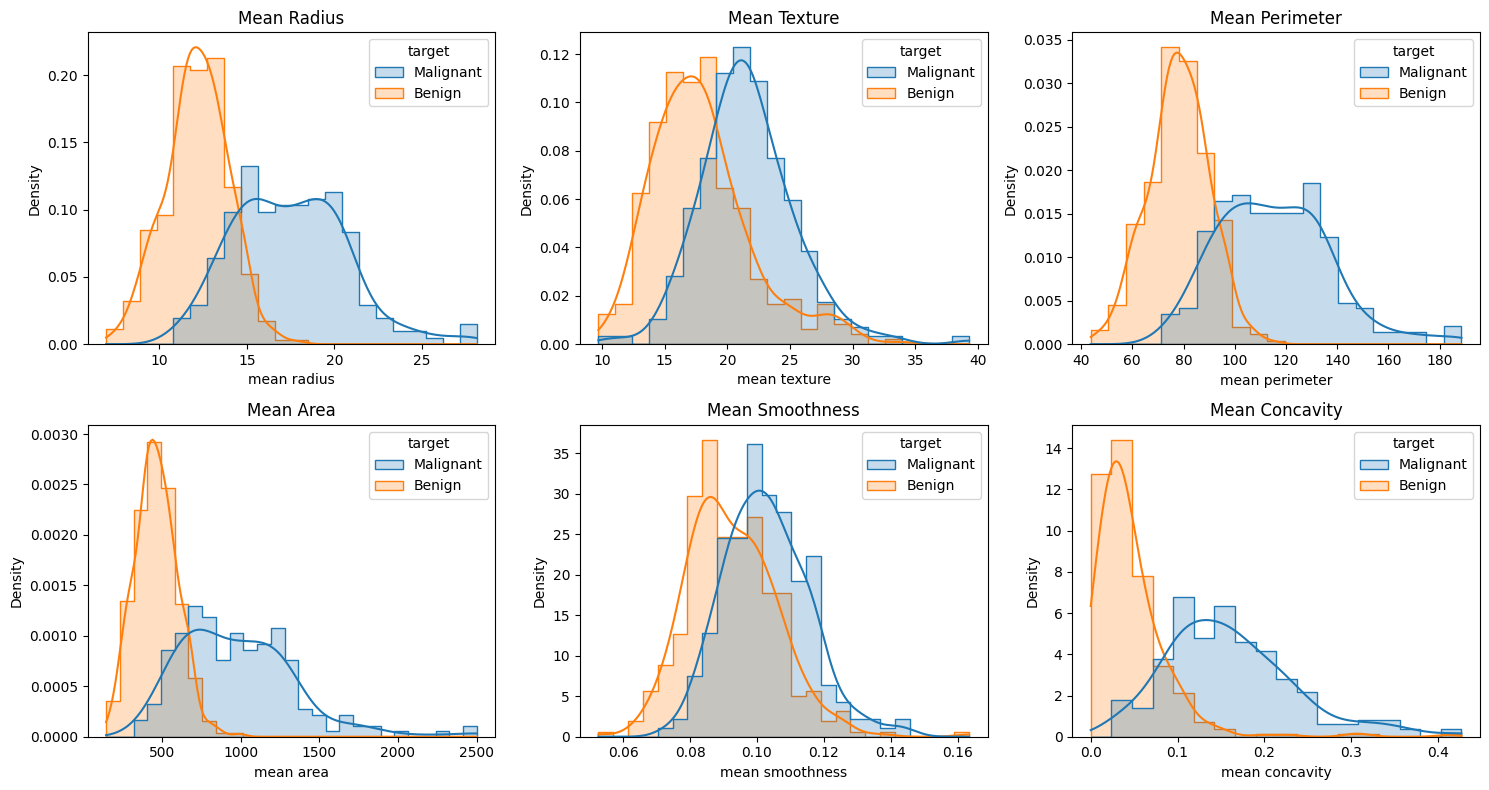

In [7]:
selected_features = ["mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness", "mean concavity"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feature in zip(axes.ravel(), selected_features):
    sns.histplot(data=X, x=feature, hue=y.map({0: "Malignant", 1: "Benign"}),
                 kde=True, element="step", stat="density", common_norm=False, ax=ax)
    ax.set_title(feature.title())
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


**Inference:** Several selected features exhibit visibly different distributions between the two diagnosis classes. This indicates that the predictors contain useful discriminatory information. Distribution overlap remains present for some variables, which motivates using multiple features and nonlinear/ensemble learning rather than relying on a single predictor.

## 8. Data Preprocessing and Train-Test Split

In [8]:
# 80–20 stratified split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training class proportions:")
display(y_train.value_counts(normalize=True).rename(index={0:"Malignant",1:"Benign"}))
print("Testing class proportions:")
display(y_test.value_counts(normalize=True).rename(index={0:"Malignant",1:"Benign"}))


Training samples: 455
Testing samples: 114
Training class proportions:


,proportion
target,
Benign,0.626374
Malignant,0.373626


Testing class proportions:


,proportion
target,
Benign,0.631579
Malignant,0.368421


### Preprocessing decisions
- No missing-value imputation is required because the dataset has no missing values.
- The target is already binary and numerically encoded.
- Feature scaling is required for SVM and is performed inside a pipeline to prevent data leakage.
- Tree-based ensemble models do not require feature scaling.
- The train-test split is stratified and fixed with `random_state=42`.

## 9. Baseline Model – Decision Tree

In [9]:
baseline_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_tree.fit(X_train, y_train)
baseline_pred = baseline_tree.predict(X_test)
baseline_prob = baseline_tree.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1 Score": f1_score(y_test, baseline_pred),
    "ROC-AUC": roc_auc_score(y_test, baseline_prob)
}
pd.Series(baseline_metrics).to_frame("Baseline Decision Tree")


,Baseline Decision Tree
Accuracy,0.912281
Precision,0.955882
Recall,0.902778
F1 Score,0.928571
ROC-AUC,0.915675


## 10. Bagging – Hyperparameter Selection

In [10]:
# Bagging uses decision trees as the high-variance base estimator.
bag_base = DecisionTreeClassifier(random_state=RANDOM_STATE)

bag_model = BaggingClassifier(
    estimator=bag_base,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

bag_param_grid = {
    "n_estimators": [3, 10, 25, 50],
    "max_samples": [0.6, 0.8, 1.0],
    "max_features": [0.7, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

bag_grid = GridSearchCV(
    bag_model,
    bag_param_grid,
    scoring={"accuracy": "accuracy", "f1": "f1"},
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)
bag_grid.fit(X_train, y_train)

print("Best Bagging parameters:", bag_grid.best_params_)
print("Best 5-fold CV F1:", bag_grid.best_score_)

bag_cv = pd.DataFrame(bag_grid.cv_results_)
bag_table = bag_cv[[
    "param_n_estimators", "param_max_samples", "param_max_features",
    "mean_test_accuracy", "mean_test_f1"
]].sort_values("mean_test_f1", ascending=False).head(10)
bag_table


Best Bagging parameters: {'max_features': 0.7, 'max_samples': 0.6, 'n_estimators': 25}
Best 5-fold CV F1: 0.9717637721766632


,param_n_estimators,param_max_samples,param_max_features,mean_test_accuracy,mean_test_f1
2,25,0.6,0.7,0.964835,0.971764
7,50,0.8,0.7,0.960440,0.968325
6,25,0.8,0.7,0.956044,0.964832
9,10,1.0,0.7,0.956044,0.964800
11,50,1.0,0.7,0.953846,0.963070
3,50,0.6,0.7,0.953846,0.963068
10,25,1.0,0.7,0.953846,0.963063
18,25,0.8,1.0,0.953846,0.962915
5,10,0.8,0.7,0.953846,0.962813
4,3,0.8,0.7,0.951648,0.961305


### Bagging CV Visualization

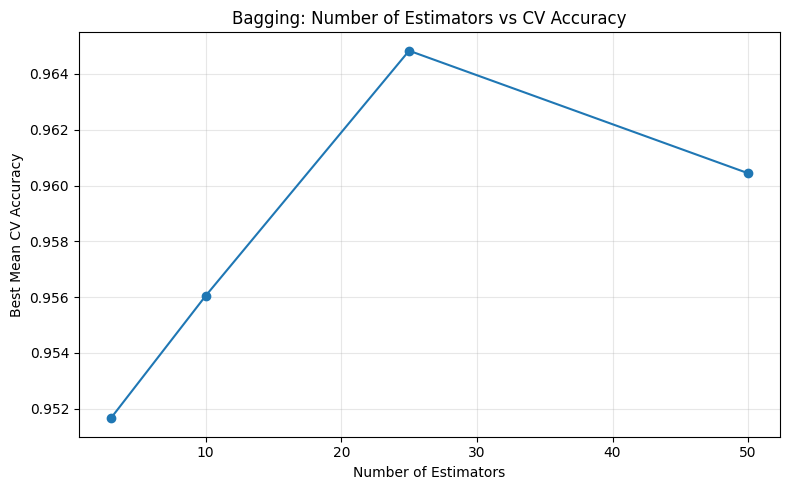

In [11]:
bag_plot = bag_cv.groupby("param_n_estimators", as_index=False)["mean_test_accuracy"].max()
plt.figure(figsize=(8, 5))
plt.plot(bag_plot["param_n_estimators"].astype(int), bag_plot["mean_test_accuracy"], marker="o")
plt.xlabel("Number of Estimators")
plt.ylabel("Best Mean CV Accuracy")
plt.title("Bagging: Number of Estimators vs CV Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "bagging_hyperparameter.png", dpi=300, bbox_inches="tight")
plt.show()


## 11. Bagging – Final Test Evaluation

In [12]:
best_bag = bag_grid.best_estimator_
best_bag.fit(X_train, y_train)
bag_pred = best_bag.predict(X_test)
bag_prob = best_bag.predict_proba(X_test)[:, 1]

def evaluate_model(name, y_true, pred, prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1 Score": f1_score(y_true, pred),
        "ROC-AUC": roc_auc_score(y_true, prob)
    }

bag_result = evaluate_model("Bagging", y_test, bag_pred, bag_prob)
pd.DataFrame([bag_result])


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Bagging,0.95614,0.958904,0.972222,0.965517,0.992725


## 12. Boosting – AdaBoost Hyperparameter Selection

In [13]:
# AdaBoost is a sequential ensemble that emphasizes samples
# that are difficult for earlier weak learners.
ada_model = AdaBoostClassifier(random_state=RANDOM_STATE)

ada_param_grid = {
    "n_estimators": [25, 50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5, 1.0]
}

ada_grid = GridSearchCV(
    ada_model,
    ada_param_grid,
    scoring={"accuracy": "accuracy", "f1": "f1"},
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)
ada_grid.fit(X_train, y_train)

print("Best AdaBoost parameters:", ada_grid.best_params_)
print("Best 5-fold CV F1:", ada_grid.best_score_)

ada_cv = pd.DataFrame(ada_grid.cv_results_)
ada_table = ada_cv[[
    "param_n_estimators", "param_learning_rate",
    "mean_test_accuracy", "mean_test_f1"
]].sort_values("mean_test_f1", ascending=False).head(10)
ada_table


Best AdaBoost parameters: {'learning_rate': 1.0, 'n_estimators': 100}
Best 5-fold CV F1: 0.9843778110944529


,param_n_estimators,param_learning_rate,mean_test_accuracy,mean_test_f1
14,100,1.0,0.980220,0.984378
15,200,1.0,0.975824,0.980869
10,100,0.5,0.973626,0.979189
7,200,0.1,0.971429,0.977269
11,200,0.5,0.969231,0.975800
13,50,1.0,0.967033,0.974002
9,50,0.5,0.967033,0.973667
12,25,1.0,0.964835,0.972142
6,100,0.1,0.960440,0.968602
8,25,0.5,0.958242,0.966707


## 13. Boosting – Gradient Boosting Hyperparameter Selection

In [14]:
gb_model = GradientBoostingClassifier(random_state=RANDOM_STATE)

gb_param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.03, 0.1, 0.2],
    "max_depth": [1, 2, 3]
}

gb_grid = GridSearchCV(
    gb_model,
    gb_param_grid,
    scoring={"accuracy": "accuracy", "f1": "f1"},
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)
gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting parameters:", gb_grid.best_params_)
print("Best 5-fold CV F1:", gb_grid.best_score_)

gb_cv = pd.DataFrame(gb_grid.cv_results_)
gb_table = gb_cv[[
    "param_n_estimators", "param_learning_rate", "param_max_depth",
    "mean_test_accuracy", "mean_test_f1"
]].sort_values("mean_test_f1", ascending=False).head(10)
gb_table


Best Gradient Boosting parameters: {'learning_rate': 0.2, 'max_depth': 1, 'n_estimators': 100}
Best 5-fold CV F1: 0.9790988716168233


,param_n_estimators,param_learning_rate,param_max_depth,mean_test_accuracy,mean_test_f1
19,100,0.2,1,0.973626,0.979099
23,150,0.2,2,0.973626,0.978945
20,150,0.2,1,0.971429,0.977330
22,100,0.2,2,0.969231,0.975496
11,150,0.1,1,0.967033,0.973941
26,150,0.2,3,0.967033,0.973820
25,100,0.2,3,0.964835,0.971927
14,150,0.1,2,0.964835,0.971894
13,100,0.1,2,0.962637,0.970219
21,50,0.2,2,0.962637,0.970126


## 14. Boosting – Final Model

In [15]:
best_ada = ada_grid.best_estimator_
best_gb = gb_grid.best_estimator_

best_ada.fit(X_train, y_train)
best_gb.fit(X_train, y_train)

ada_pred = best_ada.predict(X_test)
ada_prob = best_ada.predict_proba(X_test)[:, 1]

gb_pred = best_gb.predict(X_test)
gb_prob = best_gb.predict_proba(X_test)[:, 1]

ada_result = evaluate_model("AdaBoost", y_test, ada_pred, ada_prob)
gb_result = evaluate_model("Gradient Boosting", y_test, gb_pred, gb_prob)

pd.DataFrame([ada_result, gb_result])


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,AdaBoost,0.956140,0.946667,0.986111,0.965986,0.981812
1,Gradient Boosting,0.964912,0.959459,0.986111,0.972603,0.994709


## 15. Stacked Ensemble – Base Models and Meta Learner

In [16]:
# Heterogeneous base learners:
# 1. Scaled SVM
# 2. Gaussian Naive Bayes
# 3. Decision Tree
# Logistic Regression acts as the meta learner.

stack_estimators = [
    ("svm", Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
    ])),
    ("nb", GaussianNB()),
    ("tree", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))
]

stack_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_test)
stack_prob = stack_model.predict_proba(X_test)[:, 1]

stack_result = evaluate_model("Stacked Ensemble", y_test, stack_pred, stack_prob)
pd.DataFrame([stack_result])


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Stacked Ensemble,0.973684,0.972603,0.986111,0.97931,0.993717


### Stacking design
The SVM, Naive Bayes, and Decision Tree learners make predictions using different modelling assumptions. Their probability outputs are passed to a Logistic Regression meta-learner, which learns how to combine those outputs. This diversity is the main motivation for heterogeneous stacking.

## 16. Stacking Evaluation with 5-Fold Cross-Validation

In [17]:
stack_cv_scores = {
    "accuracy": [],
    "f1": []
}

# Explicit 5-fold evaluation on the training set.
from sklearn.model_selection import cross_validate

stack_cv = cross_validate(
    stack_model,
    X_train,
    y_train,
    cv=cv,
    scoring={"accuracy": "accuracy", "f1": "f1"},
    n_jobs=-1
)

stack_cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score"],
    "Mean 5-Fold CV": [stack_cv["test_accuracy"].mean(), stack_cv["test_f1"].mean()],
    "Std 5-Fold CV": [stack_cv["test_accuracy"].std(), stack_cv["test_f1"].std()]
})
stack_cv_summary


,Metric,Mean 5-Fold CV,Std 5-Fold CV
0,Accuracy,0.967033,0.013900
1,F1 Score,0.973660,0.011252


## 17. Final Performance Comparison

In [18]:
results = pd.DataFrame([
    baseline_metrics | {"Model": "Decision Tree"},
    bag_result,
    ada_result,
    gb_result,
    stack_result
])

results = results[["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]]
display(results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.9123,0.9559,0.9028,0.9286,0.9157
1,Bagging,0.9561,0.9589,0.9722,0.9655,0.9927
2,AdaBoost,0.9561,0.9467,0.9861,0.9660,0.9818
3,Gradient Boosting,0.9649,0.9595,0.9861,0.9726,0.9947
4,Stacked Ensemble,0.9737,0.9726,0.9861,0.9793,0.9937


## 18. Confusion Matrices

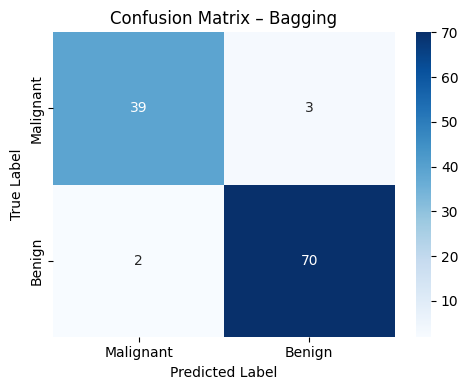

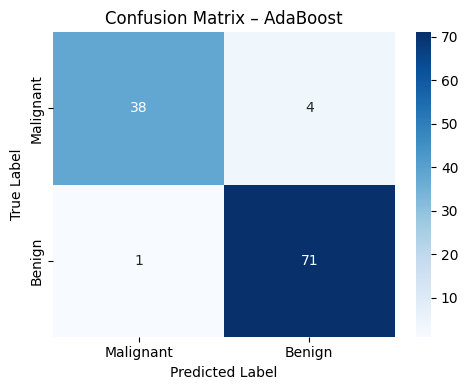

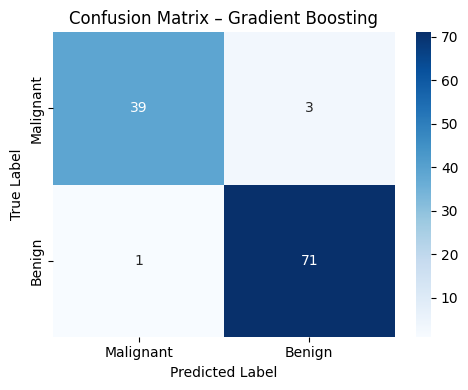

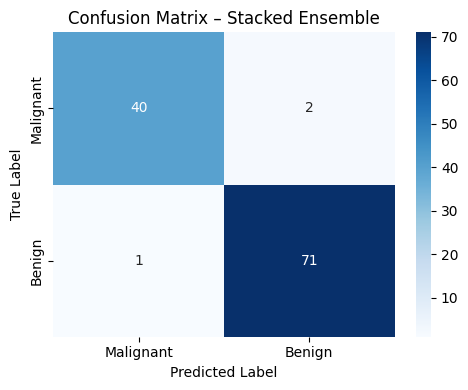

In [19]:
final_models = {
    "Bagging": (bag_pred, bag_prob),
    "AdaBoost": (ada_pred, ada_prob),
    "Gradient Boosting": (gb_pred, gb_prob),
    "Stacked Ensemble": (stack_pred, stack_prob)
}

for name, (pred, _) in final_models.items():
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Malignant", "Benign"],
                yticklabels=["Malignant", "Benign"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    filename = name.lower().replace(" ", "_") + "_confusion_matrix.png"
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


**Inference:** A confusion matrix separates correct predictions from false positives and false negatives. For this binary medical classification dataset, both types of error are important, so accuracy alone should not be used as the only measure. Precision, recall, and F1-score provide additional information about the classification behaviour.

## 19. ROC Curves and AUC

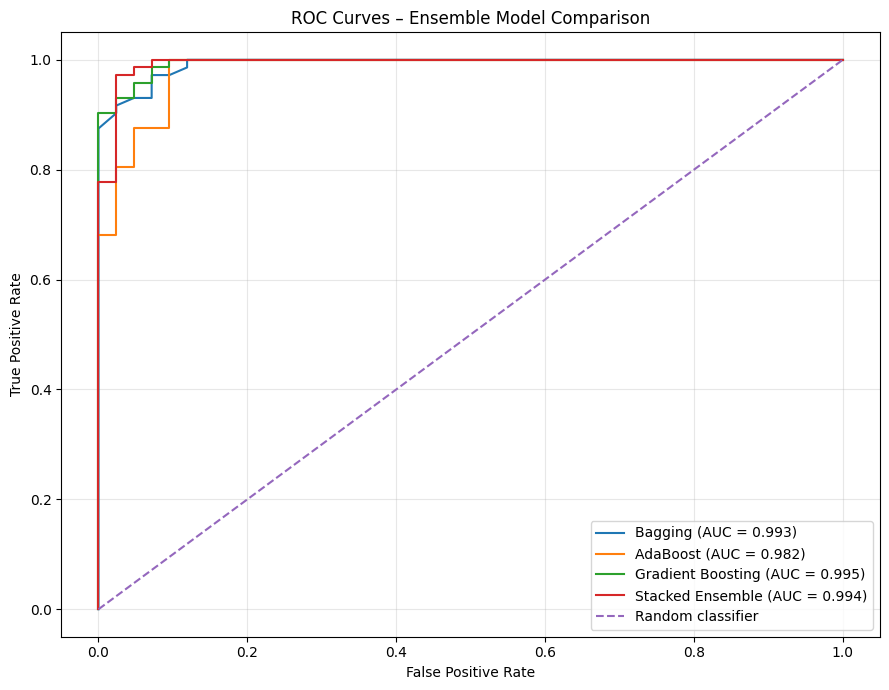

In [20]:
plt.figure(figsize=(9, 7))

for name, (pred, prob) in final_models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Ensemble Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()


## 20. Precision–Recall Curves

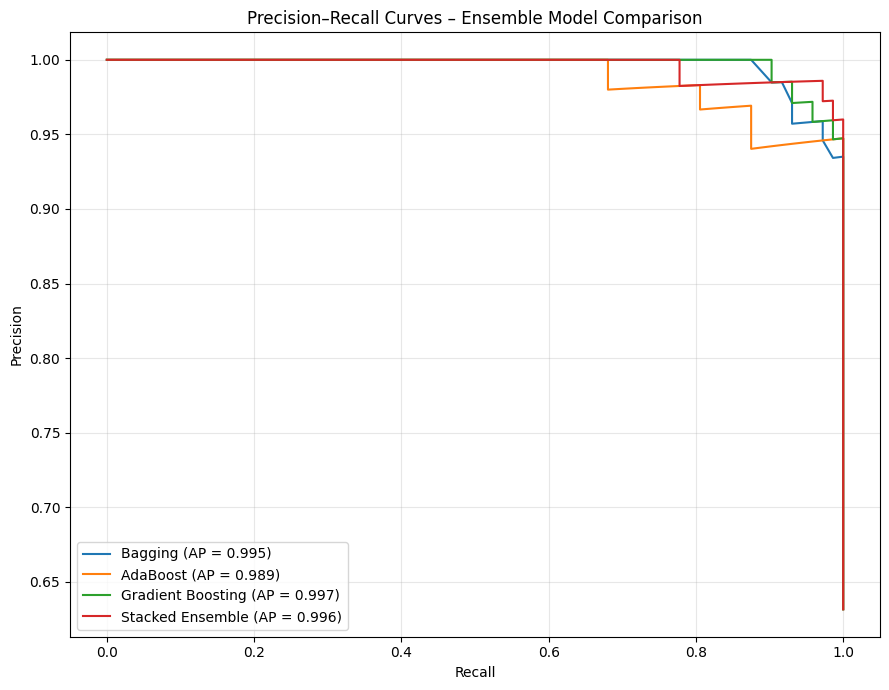

In [21]:
plt.figure(figsize=(9, 7))

for name, (pred, prob) in final_models.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves – Ensemble Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "precision_recall_curves.png", dpi=300, bbox_inches="tight")
plt.show()


## 21. Feature Importance

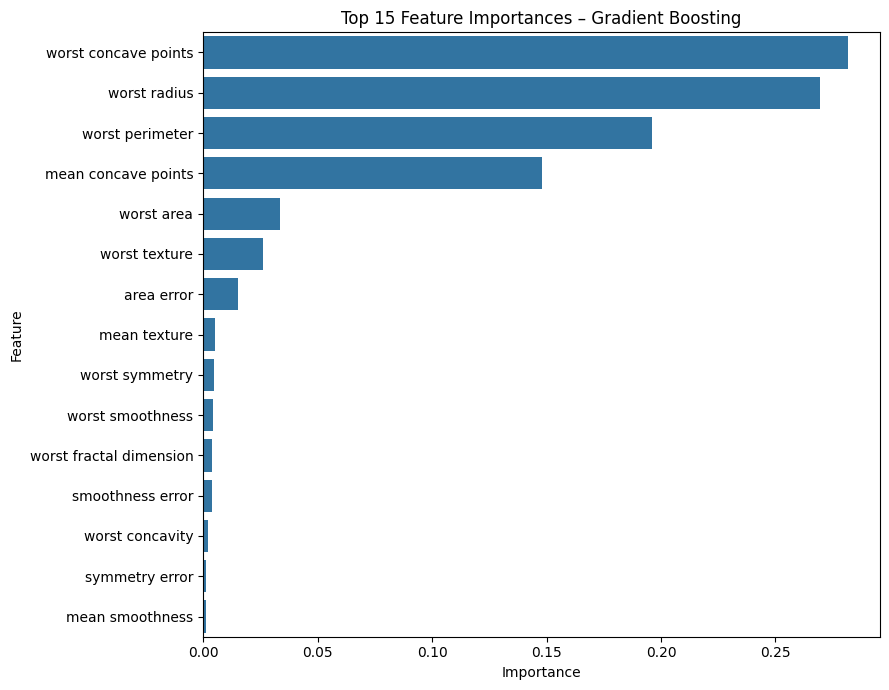

,Feature,Importance
27,worst concave points,0.281561
20,worst radius,0.269261
22,worst perimeter,0.196152
7,mean concave points,0.148202
23,worst area,0.033778
21,worst texture,0.026066
13,area error,0.015109
1,mean texture,0.005336
28,worst symmetry,0.004832
24,worst smoothness,0.004325


In [22]:
# Feature importance is directly available for tree ensembles.
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_gb.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Top 15 Feature Importances – Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

display(importance)


## 22. Bias–Variance Analysis

In [23]:
# Compare training and validation behaviour for the selected tree ensemble.
bias_variance_rows = []

for name, estimator in [
    ("Bagging", best_bag),
    ("AdaBoost", best_ada),
    ("Gradient Boosting", best_gb),
    ("Stacking", stack_model)
]:
    estimator.fit(X_train, y_train)
    train_pred = estimator.predict(X_train)
    test_pred = estimator.predict(X_test)

    bias_variance_rows.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train-Test Gap": accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred)
    })

bias_variance = pd.DataFrame(bias_variance_rows)
display(bias_variance.style.format({
    "Train Accuracy": "{:.4f}",
    "Test Accuracy": "{:.4f}",
    "Train-Test Gap": "{:.4f}"
}))


,Model,Train Accuracy,Test Accuracy,Train-Test Gap
0,Bagging,0.9890,0.9561,0.0329
1,AdaBoost,1.0000,0.9561,0.0439
2,Gradient Boosting,0.9956,0.9649,0.0307
3,Stacking,0.9912,0.9737,0.0175


### Interpretation
- **Bagging** primarily reduces variance by averaging predictions from models trained on bootstrap samples.
- **Boosting** builds models sequentially and can reduce bias by focusing later learners on difficult observations.
- **Stacking** can improve generalization when its base learners make complementary errors and the meta-learner learns an effective combination.
- The train-test accuracy gap is a diagnostic indicator, not a direct unbiased estimate of statistical bias or variance.

## 23. Observation Questions

### 1. How does Bagging reduce variance?
Bagging trains several models on different bootstrap samples and aggregates their predictions. Individual decision trees can vary considerably with changes in the training data; averaging their outputs reduces this sensitivity and therefore reduces variance.

### 2. How does Boosting address model bias?
Boosting constructs learners sequentially. Later learners place greater emphasis on observations that earlier learners handled poorly. This allows the ensemble to progressively improve the fit and can reduce systematic error, although excessive boosting can also lead to overfitting.

### 3. Why does stacking benefit from heterogeneous models?
Different algorithms impose different assumptions and produce different error patterns. Combining SVM, Naive Bayes, and a Decision Tree gives the meta-learner multiple sources of predictive information rather than repeatedly combining highly similar models.

### 4. Which ensemble method performed best and why?
Use the **test-set results produced above** to describe the observed highest metric. Do not select a model before running the notebook. Explain the result using the complete metric profile (accuracy, precision, recall, F1-score, and ROC-AUC), while noting that the 20% test set is only one held-out sample.


## 24. Final Conclusion

Bagging, AdaBoost, Gradient Boosting, and a heterogeneous Stacked Ensemble were implemented on the Wisconsin Diagnostic Breast Cancer dataset. Hyperparameters for the main ensemble methods were selected using 5-fold stratified cross-validation, followed by evaluation on an untouched 20% test set. The experiment demonstrates that ensemble methods can alter the bias–variance characteristics of individual learners and can improve robustness through averaging, sequential correction, or heterogeneous model combination. The final conclusion should be based on the numerical results generated in the preceding cells.

## 25. References

1. Scikit-learn documentation, Ensemble methods and model evaluation: https://scikit-learn.org/stable/modules/ensemble.html  
2. UCI Machine Learning Repository, Breast Cancer Wisconsin (Diagnostic) Dataset: https://archive.ics.uci.edu/  
3. F. Pedregosa et al., “Scikit-learn: Machine Learning in Python,” *Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

## 26. Export Final Results

In [24]:
# Save the final comparison table for convenient use in the LaTeX report.
results.to_csv(FIG_DIR / "final_model_results.csv", index=False)
bag_table.to_csv(FIG_DIR / "bagging_cv_results.csv", index=False)
ada_table.to_csv(FIG_DIR / "adaboost_cv_results.csv", index=False)
gb_table.to_csv(FIG_DIR / "gradient_boosting_cv_results.csv", index=False)

print("Figures and result tables have been saved to:", FIG_DIR.resolve())


Figures and result tables have been saved to: /content/figures
